# IMPORT LIBRARIES

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score

from xgboost import XGBClassifier

import warnings
warnings.filterwarnings("ignore")

# LOAD DATASET

In [7]:
df = pd.read_csv(r"C:\Users\Rupendra T\customer_churn_analysis_project\data\raw\customer_churn.csv")

In [9]:
df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [10]:
df.shape

(7043, 21)

In [11]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [12]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


# DATA CLEANING
**CONVERT TotalCharges**

In [13]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

In [14]:
# HANDLE NULLS
df["TotalCharges"].fillna(
    df["TotalCharges"].median(),
    inplace=True
)

In [15]:
# CHECK NULLS
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [16]:
# REMOVE customerID
df.drop("customerID", axis=1, inplace=True)

# EDA  CHURN DISTRIBUTION

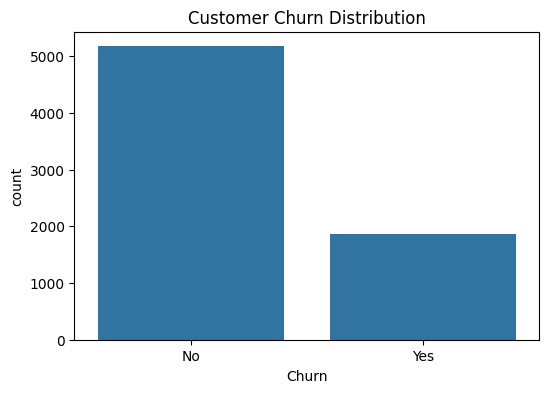

In [17]:
plt.figure(figsize=(6,4))

sns.countplot(x='Churn', data=df)

plt.title("Customer Churn Distribution")

plt.show()

# BUSINESS INSIGHT
Customers leaving the company are significant.

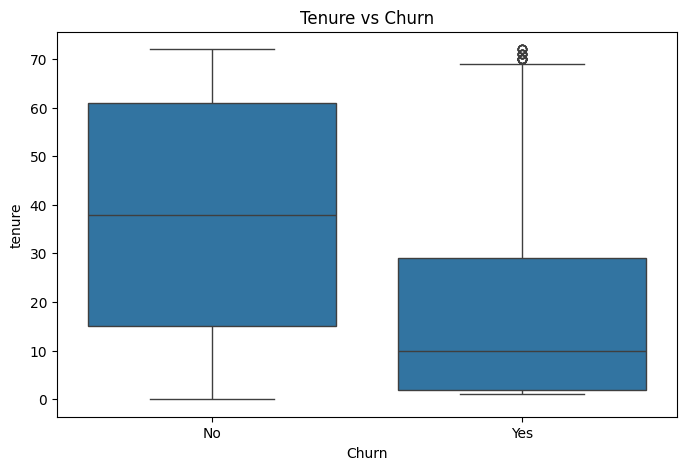

In [18]:
# TENURE VS CHURN
plt.figure(figsize=(8,5))

sns.boxplot(x='Churn', y='tenure', data=df)

plt.title("Tenure vs Churn")

plt.show()

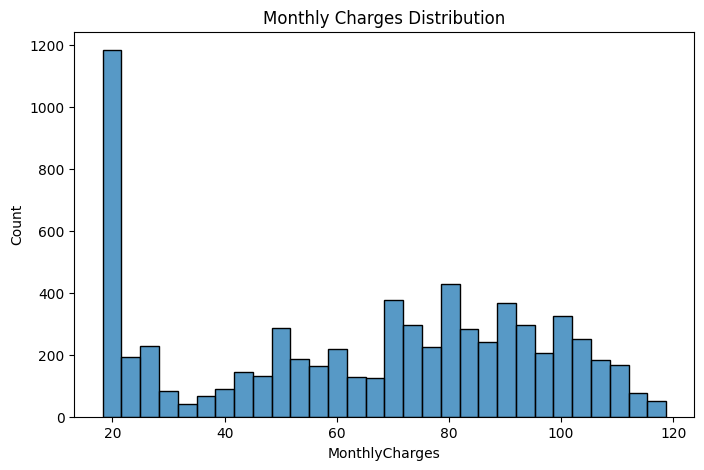

In [19]:
# MONTHLY CHARGES
plt.figure(figsize=(8,5))

sns.histplot(df['MonthlyCharges'], bins=30)

plt.title("Monthly Charges Distribution")

plt.show()

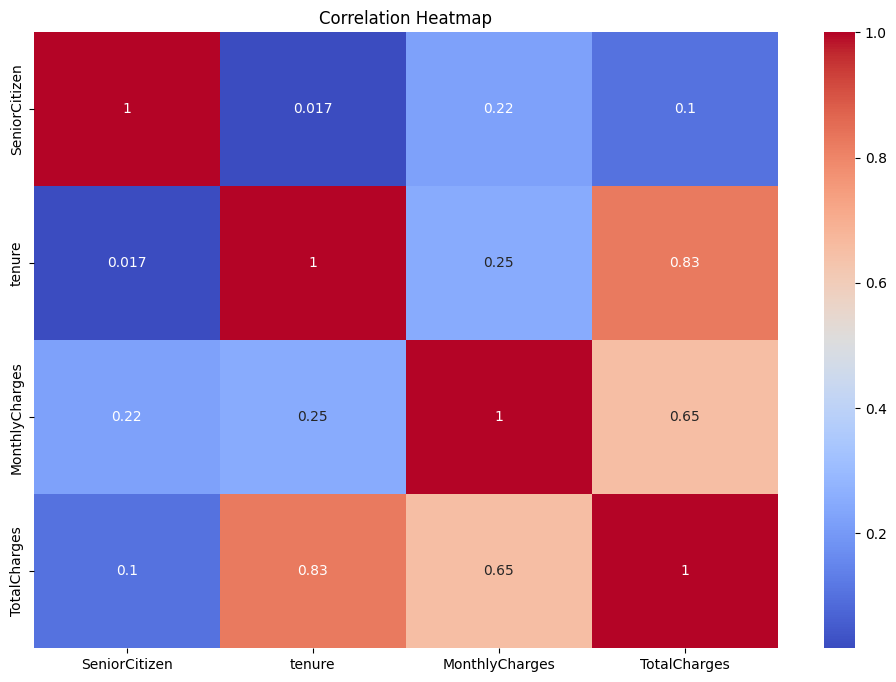

In [20]:
# CORRELATION HEATMAP
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

In [45]:
if "customerID" in df.columns:
    df.drop("customerID", axis=1, inplace=True)

# FEATURE ENGINEERING

In [46]:
# FEATURE ENGINEERING

df["TenureMonthlyRatio"] = (
    df["tenure"] /
    (df["MonthlyCharges"] + 1)
)

df["AvgRevenuePerMonth"] = (
    df["TotalCharges"] /
    (df["tenure"] + 1)
)

df["TotalServices"] = (
    (df["PhoneService"] == "Yes").astype(int) +
    (df["OnlineSecurity"] == "Yes").astype(int) +
    (df["OnlineBackup"] == "Yes").astype(int) +
    (df["DeviceProtection"] == "Yes").astype(int) +
    (df["TechSupport"] == "Yes").astype(int) +
    (df["StreamingTV"] == "Yes").astype(int) +
    (df["StreamingMovies"] == "Yes").astype(int)
)

df["HighRiskCustomer"] = (
    ((df["Contract"] == "Month-to-month") &
     (df["PaperlessBilling"] == "Yes"))
).astype(int)

# ONE HOT ENCODING

df = pd.get_dummies(
    df,
    drop_first=True
)

print(df.shape)

df.head()

(7043, 26)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,PaymentMethod,MonthlyCharges,TotalCharges,Churn,AvgMonthlySpend,tenure_group,TenureMonthlyRatio,AvgRevenuePerMonth,TotalServices,HighRiskCustomer
0,0,0,1,0,1,0,1,0,0,2,...,2,29.85,29.85,0,14.925000,1,0.032415,14.925000,0,0
1,1,0,0,0,34,1,0,0,2,0,...,3,56.95,1889.50,0,53.985714,3,0.586713,53.985714,0,0
2,1,0,0,0,2,1,0,0,2,2,...,3,53.85,108.15,1,36.050000,1,0.036463,36.050000,0,0
3,1,0,0,0,45,0,1,0,2,0,...,0,42.30,1840.75,0,40.016304,3,1.039261,40.016304,0,0
4,0,0,0,0,2,1,0,1,0,0,...,2,70.70,151.65,1,50.550000,1,0.027894,50.550000,0,0


# TENURE GROUP

In [23]:
df["tenure_group"] = pd.cut(
    df["tenure"],
    bins=[0,12,24,48,72],
    labels=[1,2,3,4]
)

In [25]:
#CONVERT CATEGORY
df["tenure_group"] = pd.cut(
    df["tenure"],
    bins=[0,12,24,48,72],
    labels=[1,2,3,4],
    include_lowest=True
)

df["tenure_group"] = df["tenure_group"].astype(int)

# TRAIN TEST SPLIT

In [50]:
print(df.columns.tolist())

['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn', 'AvgMonthlySpend', 'tenure_group', 'TenureMonthlyRatio', 'AvgRevenuePerMonth', 'TotalServices', 'HighRiskCustomer']


In [51]:
X = df.drop("Churn", axis=1)

y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42, stratify=y)

# SCALING

In [52]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

numeric_cols = [
    'tenure',
    'MonthlyCharges',
    'TotalCharges',
    'TenureMonthlyRatio',
    'AvgRevenuePerMonth',
    'TotalServices'
]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols)
    ],
    remainder='passthrough'
)

X_train = preprocessor.fit_transform(X_train)

X_test = preprocessor.transform(X_test)

In [53]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print(y_train_smote.value_counts())

Churn
0    4139
1    4139
Name: count, dtype: int64


# LOGISTIC REGRESSION

In [29]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train_scaled, y_train)

lr_pred = lr.predict(X_test_scaled)

In [30]:
# EVALUATION
print("Accuracy:", accuracy_score(y_test, lr_pred))

print(classification_report(y_test, lr_pred))

Accuracy: 0.8041163946061036
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.66      0.54      0.59       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.73      1409
weighted avg       0.80      0.80      0.80      1409



# RANDOM FOREST

In [31]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)
# EVALUATE
print("Accuracy:", accuracy_score(y_test, rf_pred))

print(classification_report(y_test, rf_pred))

Accuracy: 0.794889992902768
              precision    recall  f1-score   support

           0       0.83      0.90      0.87      1035
           1       0.65      0.50      0.56       374

    accuracy                           0.79      1409
   macro avg       0.74      0.70      0.71      1409
weighted avg       0.78      0.79      0.79      1409



# XGBOOST

In [56]:
xgb = XGBClassifier(
    n_estimators=2000,
    learning_rate=0.01,
    max_depth=4,
    min_child_weight=1,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=0.3,
    reg_alpha=0.5,
    reg_lambda=2,
    objective='binary:logistic',
    eval_metric='logloss',
    scale_pos_weight=3,
    random_state=42
)

xgb.fit(X_train_smote, y_train_smote)
xgb.fit(X_train_smote, y_train_smote)
y_probs = xgb.predict_proba(X_test)[:,1]

y_pred = (y_probs > 0.60).astype(int)
print("Accuracy:", accuracy_score(y_test, y_pred))

print("ROC AUC:", roc_auc_score(y_test, y_probs))

print(classification_report(y_test, y_pred))

Accuracy: 0.759403832505323
ROC AUC: 0.838297295202666
              precision    recall  f1-score   support

           0       0.89      0.77      0.82      1035
           1       0.53      0.73      0.62       374

    accuracy                           0.76      1409
   macro avg       0.71      0.75      0.72      1409
weighted avg       0.79      0.76      0.77      1409



In [39]:
y_probs = xgb.predict_proba(X_test)[:,1]

In [40]:
y_pred_custom = (y_probs > 0.35).astype(int)

In [41]:
print("Accuracy:", accuracy_score(y_test, y_pred_custom))

print("ROC AUC:", roc_auc_score(y_test, y_pred_custom))

print(classification_report(y_test, y_pred_custom))

Accuracy: 0.7558552164655784
ROC AUC: 0.7373362783848718
              precision    recall  f1-score   support

           0       0.88      0.78      0.82      1035
           1       0.53      0.70      0.60       374

    accuracy                           0.76      1409
   macro avg       0.70      0.74      0.71      1409
weighted avg       0.78      0.76      0.77      1409



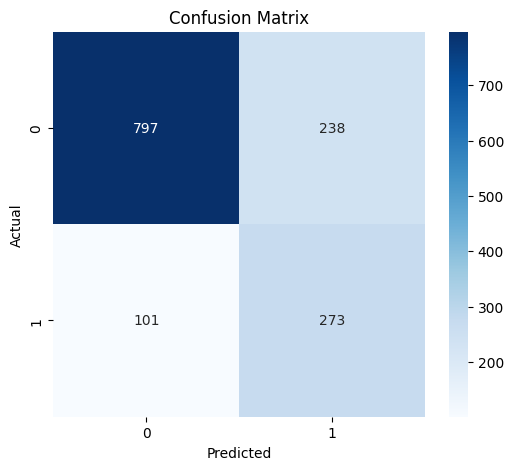

In [59]:
#confusion_matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

# ROC CURVE VISUALIZATION

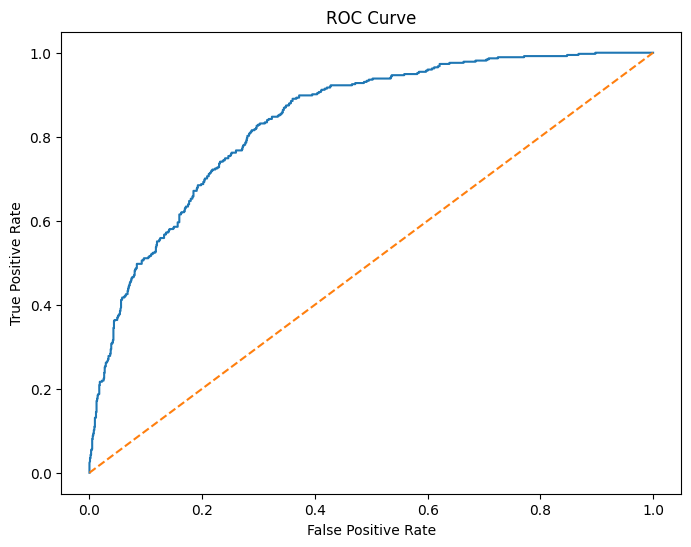

In [58]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_probs
)

plt.figure(figsize=(8,6))

plt.plot(fpr, tpr)

plt.plot([0,1], [0,1], linestyle='--')

plt.title("ROC Curve")

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.show()

# FEATURE IMPORTANCE CHART

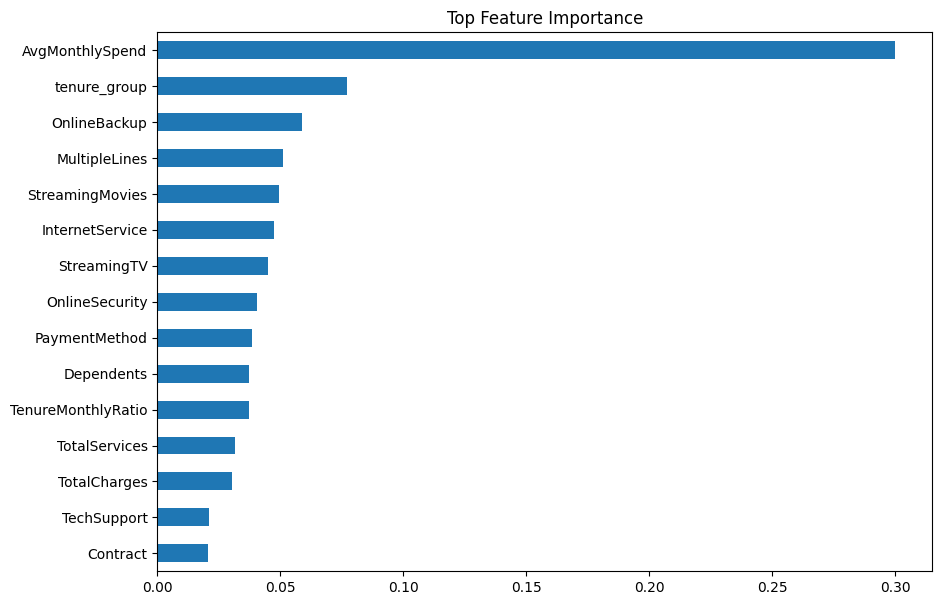

In [57]:
importance = pd.Series(
    xgb.feature_importances_,
    index=X.columns
)

importance.sort_values().tail(15).plot(
    kind='barh',
    figsize=(10,7)
)

plt.title("Top Feature Importance")

plt.show()

## BUSINESS INSIGHTS
1. Customers with month-to-month contracts show highest churn risk.

2. Customers with short tenure are more likely to leave.

3. High monthly charges contribute significantly to churn probability.

4. Customers with low engagement services have higher churn rates.

5. Long-term customers show strong retention behavior.

## BUSINESS RECOMMENDATIONS
1. Offer discounts for long-term contracts.

2. Improve onboarding for first-year customers.

3. Launch retention campaigns for high monthly charge customers.

4. Bundle engagement services to improve customer stickiness.

5. Use churn prediction model for proactive retention outreach.

In [60]:
df.to_csv(
    "../data/cleaned/cleaned_customer_churn.csv",
    index=False
)

In [61]:
import joblib

joblib.dump(
    xgb,
    "../models/churn_prediction_model.pkl"
)

['../models/churn_prediction_model.pkl']

In [64]:
import pandas as pd

# 1. Load your existing cleaned file
df = pd.read_csv(r"C:\Users\Rupendra T\customer_churn_analysis_project\data\cleaned\cleaned_customer_churn.csv")

# 2. Map the numbers back to real words for Power BI
df['Gender_Label'] = df['gender'].map({0: 'Female', 1: 'Male'})
df['Contract_Label'] = df['Contract'].map({0: 'Month-to-month', 1: 'One year', 2: 'Two year'})
df['Internet_Service_Label'] = df['InternetService'].map({0: 'DSL', 1: 'Fiber optic', 2: 'No Internet'})
df['Payment_Method_Label'] = df['PaymentMethod'].map({
    0: 'Bank transfer', 
    1: 'Credit card', 
    2: 'Electronic check', 
    3: 'Mailed check'
})
df['Churn_Status'] = df['Churn'].map({0: 'Stayed', 1: 'Churned'})

# 3. Standardize Tenure Groups to match your reference image perfectly
def get_tenure_group(months):
    if months <= 6: return "0-6 Months (High Risk)"
    elif months <= 12: return "6-12 Months"
    elif months <= 24: return "1-2 Years"
    elif months <= 48: return "2-4 Years"
    else: return "4+ Years"

df['Tenure_Group'] = df['tenure'].apply(get_tenure_group)

# 4. Save this as a brand new file
df.to_csv("powerbi_ready_churn.csv", index=False)
print("🎉 Success! 'powerbi_ready_churn.csv' has been created and is ready for Power BI!")


🎉 Success! 'powerbi_ready_churn.csv' has been created and is ready for Power BI!


In [71]:
import pandas as pd
import os

# Define your exact target directory
output_dir = r"C:\Users\Rupendra T\customer_churn_analysis_project\data\cleaned"
file_name = "powerbi_ready_churn.csv"

# This combines the folder path and the file name
output_path = os.path.join(output_dir, file_name)

# This command ensures the folder exists, if it doesn't, it creates it
os.makedirs(output_dir, exist_ok=True)

# Load your data
df = pd.read_csv(r"C:\Users\Rupendra T\customer_churn_analysis_project\data\cleaned\cleaned_customer_churn.csv")

# --- Adding the labels ---
df['Gender_Label'] = df['gender'].map({0: 'Female', 1: 'Male'})
df['Contract_Label'] = df['Contract'].map({0: 'Month-to-month', 1: 'One year', 2: 'Two year'})
df['Internet_Service_Label'] = df['InternetService'].map({0: 'DSL', 1: 'Fiber optic', 2: 'No Internet'})
df['Payment_Method_Label'] = df['PaymentMethod'].map({
    0: 'Bank transfer', 
    1: 'Credit card', 
    2: 'Electronic check', 
    3: 'Mailed check'
})
df['Churn_Status'] = df['Churn'].map({0: 'Stayed', 1: 'Churned'})

# Tenure grouping
def get_tenure_group(months):
    if months <= 6: return "0-6 Months (High Risk)"
    elif months <= 12: return "6-12 Months"
    elif months <= 24: return "1-2 Years"
    elif months <= 48: return "2-4 Years"
    else: return "4+ Years"

df['Tenure_Group'] = df['tenure'].apply(get_tenure_group)

# --- Save to the specific folder ---
df.to_csv(output_path, index=False)

print(f"✅ Success! Your file is saved here:\n{output_path}")

✅ Success! Your file is saved here:
C:\Users\Rupendra T\customer_churn_analysis_project\data\cleaned\powerbi_ready_churn.csv
